# Experiment 4: Perceptron vs Multilayer Perceptron with Hyperparameter Tuning


**Objective:** Implement and compare a Single-Layer Perceptron (PLA, built from scratch) against a
Multilayer Perceptron (MLP) with tuned hyperparameters, on the English handwritten characters dataset
(62 classes: `0-9`, `A-Z`, `a-z`).

## 1. Dataset Loading & Preprocessing

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_curve, auc)

# Set path relative to your local workspace directory
DATA_DIR = os.path.join('assignment', 'english_dataset')

# Load dataset
df = pd.read_csv(os.path.join(DATA_DIR, 'english.csv'))
print(df.shape)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'assignment\\english_dataset\\english.csv'

In [ ]:
import time
import numpy as np
IMG_SIZE = 32

def load_images(df, data_dir):
    X = np.zeros((len(df), IMG_SIZE * IMG_SIZE), dtype=np.float32)
    for i, rel_path in enumerate(df['image']):
        img = Image.open(os.path.join(data_dir, rel_path)).convert('L').resize((IMG_SIZE, IMG_SIZE))
        X[i] = np.asarray(img, dtype=np.float32).flatten()
    return X / 255.0

t0 = time.time()
X = load_images(df, DATA_DIR)

labels_sorted = sorted(df['label'].unique())
label_to_idx = {l: i for i, l in enumerate(labels_sorted)}
idx_to_label = {i: l for l, i in label_to_idx.items()}
y = df['label'].map(label_to_idx).values

print(f'Loaded {X.shape[0]} images of size {IMG_SIZE}x{IMG_SIZE} in {time.time()-t0:.1f}s')
print(f'Feature matrix: {X.shape}, Classes: {len(labels_sorted)}')

Loaded 3410 images of size 32x32 in 62.8s
Feature matrix: (3410, 1024), Classes: 62


## 2. Exploratory Data Analysis

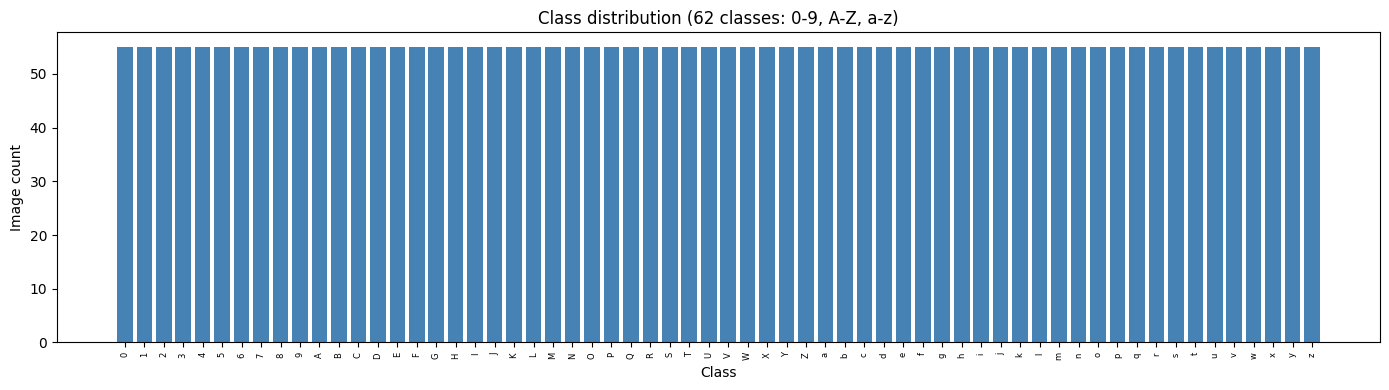

Min/Max/Mean images per class: 55 55 55.0


In [ ]:
counts = df['label'].value_counts().sort_index()
plt.figure(figsize=(14, 4))
plt.bar(range(len(counts)), counts.values, color='steelblue')
plt.xticks(range(len(counts)), counts.index, rotation=90, fontsize=6)
plt.xlabel('Class')
plt.ylabel('Image count')
plt.title('Class distribution (62 classes: 0-9, A-Z, a-z)')
plt.tight_layout()
plt.show()

print('Min/Max/Mean images per class:', counts.min(), counts.max(), counts.mean())

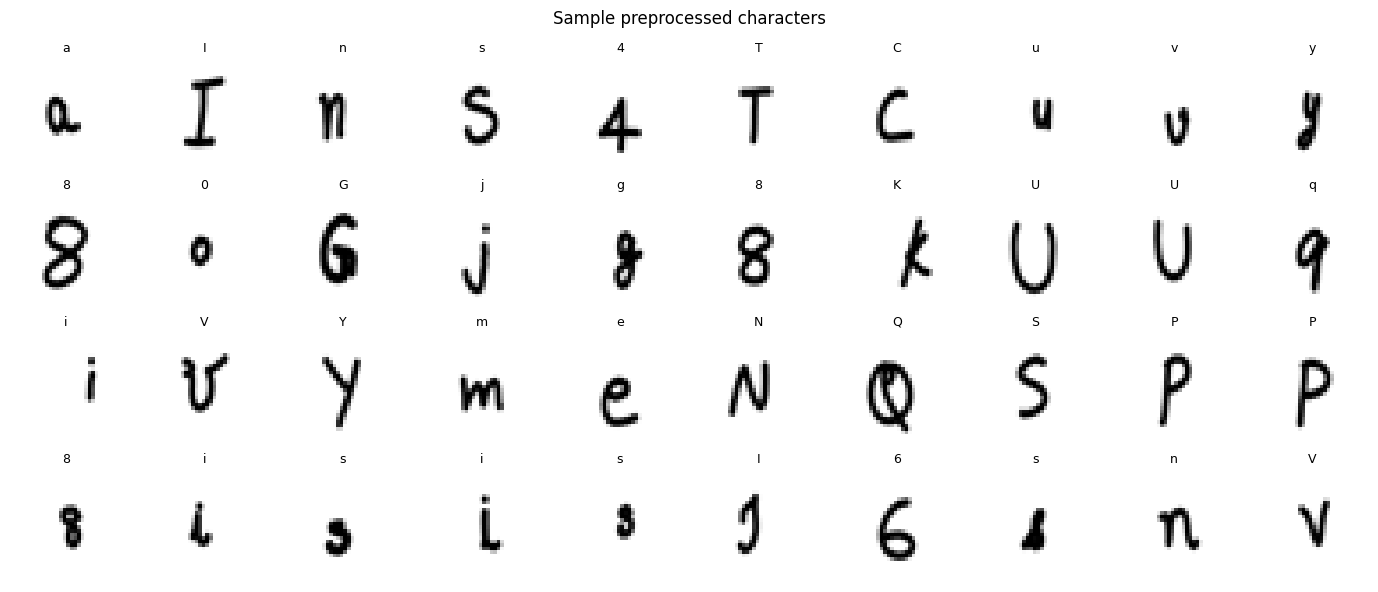

In [ ]:
fig, axes = plt.subplots(4, 10, figsize=(14, 6))
rng = np.random.RandomState(0)
sample_idx = rng.choice(len(df), 40, replace=False)
for ax, i in zip(axes.flat, sample_idx):
    ax.imshow(X[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    ax.set_title(df['label'].iloc[i], fontsize=9)
    ax.axis('off')
plt.suptitle('Sample preprocessed characters')
plt.tight_layout()
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (2728, 1024) Test: (682, 1024)


## 3. Model A: Single-Layer Perceptron (PLA) — from scratch

Implements the perceptron weight-update rule $w_{t+1} = w_t + \eta(y-\hat y)x$ directly with `numpy`
(no ML library perceptron class). Multi-class support uses **One-vs-Rest**: one weight vector per class,
all trained jointly in mini-batches, with a step activation and `argmax` for final class prediction.

In [ ]:
class PerceptronOvR:
    def __init__(self, n_features, n_classes, eta=0.05, epochs=50, batch_size=32, seed=42):
        self.eta = eta
        self.epochs = epochs
        self.batch_size = batch_size
        self.rng = np.random.RandomState(seed)
        self.W = np.zeros((n_features + 1, n_classes))
        self.n_classes = n_classes
        self.loss_history = []

    @staticmethod
    def _add_bias(X):
        return np.hstack([X, np.ones((len(X), 1))])

    def fit(self, X, y):
        Xb = self._add_bias(X)
        Y_ovr = np.where(y[:, None] == np.arange(self.n_classes)[None, :], 1, -1)
        n = len(Xb)
        for epoch in range(self.epochs):
            order = self.rng.permutation(n)
            for start in range(0, n, self.batch_size):
                bidx = order[start:start + self.batch_size]
                xb, yb = Xb[bidx], Y_ovr[bidx]
                scores = xb @ self.W
                pred = np.where(scores >= 0, 1, -1)
                error = yb - pred
                self.W += self.eta * (xb.T @ error) / len(xb)

            scores_full = Xb @ self.W
            pred_labels = np.argmax(scores_full, axis=1)
            train_err = 1 - np.mean(pred_labels == y)
            self.loss_history.append(train_err)
        return self

    def decision_function(self, X):
        return self._add_bias(X) @ self.W

    def predict(self, X):
        return np.argmax(self.decision_function(X), axis=1)

In [ ]:
t0 = time.time()
pla = PerceptronOvR(n_features=X_train.shape[1], n_classes=len(labels_sorted),
                     eta=0.05, epochs=50, batch_size=32)
pla.fit(X_train, y_train)
pla_train_time = time.time() - t0

y_pred_pla = pla.predict(X_test)
pla_acc = accuracy_score(y_test, y_pred_pla)
print(f'PLA trained in {pla_train_time:.1f}s, test accuracy = {pla_acc*100:.2f}%')
print(f'Final training error rate: {pla.loss_history[-1]*100:.2f}%')

PLA trained in 2.8s, test accuracy = 5.43%
Final training error rate: 93.00%


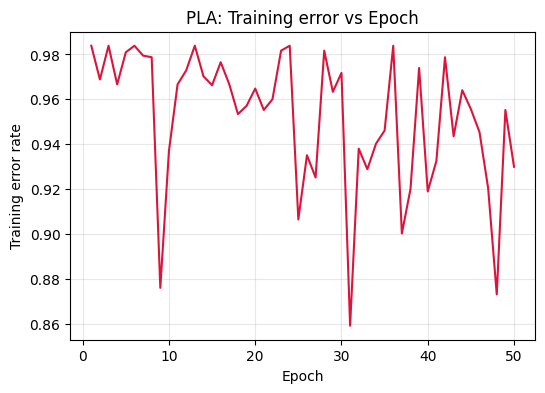

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(pla.loss_history) + 1), pla.loss_history, color='crimson')
plt.xlabel('Epoch')
plt.ylabel('Training error rate')
plt.title('PLA: Training error vs Epoch')
plt.grid(alpha=0.3)
plt.show()

## 4. Model B: Multilayer Perceptron (MLP) with Hyperparameter Tuning

Three configurations (hidden layers, activation, optimizer, learning rate, batch size) are trained and
compared, following the tuning grid from the assignment.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

print('GPU available:', tf.config.list_physical_devices('GPU'))

class KerasMLPWrapper:
    def __init__(self, hidden_layer_sizes, activation, solver, learning_rate_init,
                 batch_size, n_classes, n_features, max_iter=1000,
                 n_iter_no_change=10, tol=1e-4, seed=42):
        tf.random.set_seed(seed)
        model = models.Sequential()
        model.add(layers.Input(shape=(n_features,)))
        for units in hidden_layer_sizes:
            model.add(layers.Dense(units, activation=activation))
        model.add(layers.Dense(n_classes, activation='softmax'))

        opt = tf.keras.optimizers.Adam(learning_rate=learning_rate_init) if solver == 'adam' \
              else tf.keras.optimizers.SGD(learning_rate=learning_rate_init)

        model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        self.model = model
        self.max_iter = max_iter
        self.n_iter_no_change = n_iter_no_change
        self.tol = tol
        self.batch_size = batch_size

    def fit(self, X, y):
        es = callbacks.EarlyStopping(monitor='loss', min_delta=self.tol,
                                      patience=self.n_iter_no_change,
                                      restore_best_weights=True)
        hist = self.model.fit(X, y, epochs=self.max_iter, batch_size=self.batch_size,
                               callbacks=[es], verbose=0)
        self.loss_curve_ = hist.history['loss']
        self.n_iter_ = len(self.loss_curve_)
        self.loss_ = self.loss_curve_[-1]
        return self

    def predict(self, X):
        return np.argmax(self.model.predict(X, verbose=0), axis=1)

    def predict_proba(self, X):
        return self.model.predict(X, verbose=0)


n_classes = len(labels_sorted)
n_features = X_train.shape[1]

mlp_configs = [
    dict(name='1 (128)',        hidden_layer_sizes=(128,),          activation='relu', solver='sgd',  learning_rate_init=0.01,   batch_size=32),
    dict(name='2 (256-128)',    hidden_layer_sizes=(256, 128),      activation='relu', solver='adam', learning_rate_init=0.001,  batch_size=64),
    dict(name='3 (512-256-128)',hidden_layer_sizes=(512, 256, 128), activation='tanh', solver='adam', learning_rate_init=0.0005, batch_size=64),
]

tuning_results = []
trained_mlps = []

for cfg in mlp_configs:
    params = {k: v for k, v in cfg.items() if k != 'name'}
    t0 = time.time()
    clf = KerasMLPWrapper(n_classes=n_classes, n_features=n_features,
                           max_iter=1000, n_iter_no_change=10, tol=1e-4, **params)
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test))
    elapsed = time.time() - t0
    tuning_results.append({
        'Hidden Layers': cfg['name'], 'Activation': cfg['activation'].capitalize(),
        'Optimizer': cfg['solver'].upper(), 'Learning Rate': cfg['learning_rate_init'],
        'Batch Size': cfg['batch_size'], 'Accuracy (%)': round(acc * 100, 2),
        'Epochs Run': clf.n_iter_, 'Final Loss': round(clf.loss_, 4)
    })
    trained_mlps.append(clf)
    print(f"{cfg['name']:16s} acc={acc*100:5.2f}%  n_iter={clf.n_iter_:3d}  loss={clf.loss_:.4f}  time={elapsed:.1f}s")

tuning_df = pd.DataFrame(tuning_results)
tuning_df

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


I0000 00:00:1787207167.790602      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1787207170.032474     127 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1 (128)          acc=39.15%  n_iter=1000  loss=0.1478  time=205.8s
2 (256-128)      acc=41.20%  n_iter=120  loss=1.0516  time=18.8s
3 (512-256-128)  acc=45.75%  n_iter=176  loss=0.3174  time=28.4s


,Hidden Layers,Activation,Optimizer,Learning Rate,Batch Size,Accuracy (%),Epochs Run,Final Loss
0,1 (128),Relu,SGD,0.0100,32,39.15,1000,0.1478
1,2 (256-128),Relu,ADAM,0.0010,64,41.20,120,1.0516
2,3 (512-256-128),Tanh,ADAM,0.0005,64,45.75,176,0.3174


Best MLP configuration: 3 (512-256-128) -> test accuracy 45.75 %


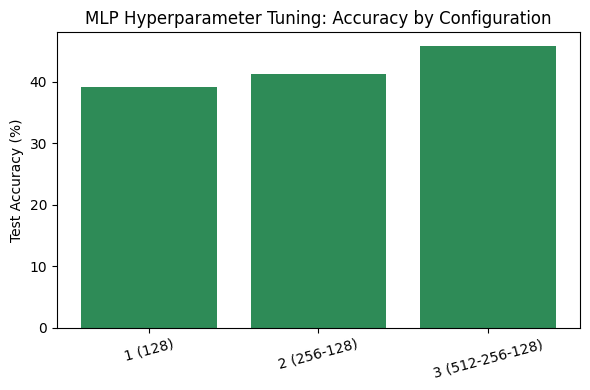

In [ ]:
best_idx = tuning_df['Accuracy (%)'].idxmax()
best_mlp = trained_mlps[best_idx]
best_cfg = mlp_configs[best_idx]
print('Best MLP configuration:', best_cfg['name'], '-> test accuracy',
      tuning_df.loc[best_idx, 'Accuracy (%)'], '%')

plt.figure(figsize=(6, 4))
plt.bar(tuning_df['Hidden Layers'], tuning_df['Accuracy (%)'], color='seagreen')
plt.ylabel('Test Accuracy (%)')
plt.title('MLP Hyperparameter Tuning: Accuracy by Configuration')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [ ]:
y_pred_mlp = best_mlp.predict(X_test)
mlp_acc = accuracy_score(y_test, y_pred_mlp)
print(f'Best MLP (Tuned) test accuracy: {mlp_acc*100:.2f}%')

Best MLP (Tuned) test accuracy: 45.75%


## 5. Performance Evaluation

In [ ]:
def metrics_row(y_true, y_pred):
    return {
        'Accuracy (%)': round(accuracy_score(y_true, y_pred) * 100, 2),
        'Precision': round(precision_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'Recall': round(recall_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'F1-score': round(f1_score(y_true, y_pred, average='macro', zero_division=0), 4),
    }

table1 = pd.DataFrame([
    {'Model': 'PLA (OvR)', **metrics_row(y_test, y_pred_pla)},
    {'Model': 'MLP (Tuned)', **metrics_row(y_test, y_pred_mlp)},
])
print('Table 1: Overall Performance Comparison between PLA and MLP')
table1

Table 1: Overall Performance Comparison between PLA and MLP


,Model,Accuracy (%),Precision,Recall,F1-score
0,PLA (OvR),5.43,0.0881,0.0543,0.0313
1,MLP (Tuned),45.75,0.5096,0.4575,0.4601


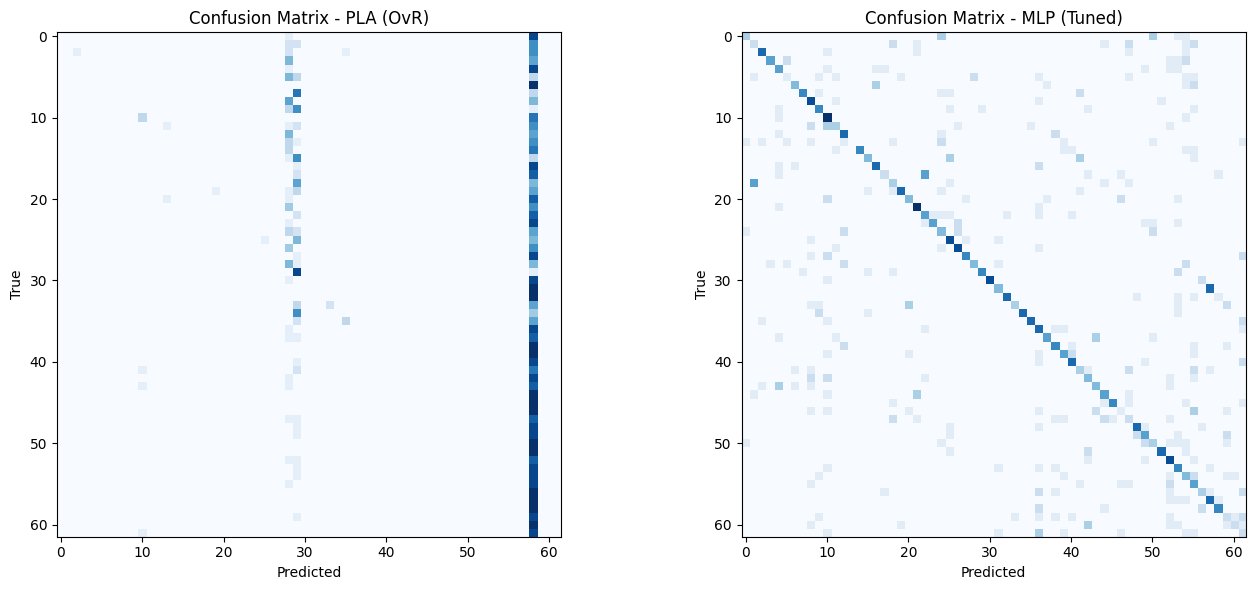

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (name, pred) in zip(axes, [('PLA (OvR)', y_pred_pla), ('MLP (Tuned)', y_pred_mlp)]):
    cm = confusion_matrix(y_test, pred, labels=range(len(labels_sorted)))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(f'Confusion Matrix - {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
plt.tight_layout()
plt.show()

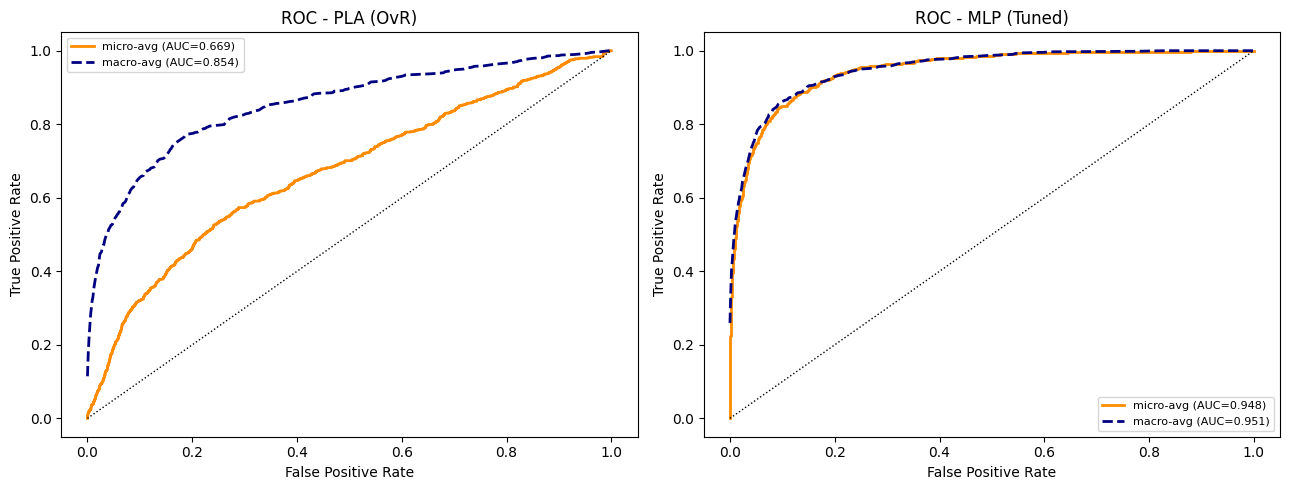

PLA  micro/macro AUC: 0.669 / 0.854
MLP  micro/macro AUC: 0.948 / 0.951


In [ ]:
def plot_roc(ax, y_true, scores, n_classes, title):
    y_bin = label_binarize(y_true, classes=range(n_classes))
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], scores[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    fpr_micro, tpr_micro, _ = roc_curve(y_bin.ravel(), scores.ravel())
    auc_micro = auc(fpr_micro, tpr_micro)

    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    auc_macro = auc(all_fpr, mean_tpr)

    ax.plot(fpr_micro, tpr_micro, label=f'micro-avg (AUC={auc_micro:.3f})', color='darkorange', lw=2)
    ax.plot(all_fpr, mean_tpr, label=f'macro-avg (AUC={auc_macro:.3f})', color='navy', lw=2, linestyle='--')
    ax.plot([0, 1], [0, 1], 'k:', lw=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(title)
    ax.legend(fontsize=8)
    return auc_micro, auc_macro

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
pla_auc = plot_roc(axes[0], y_test, pla.decision_function(X_test), len(labels_sorted), 'ROC - PLA (OvR)')
mlp_auc = plot_roc(axes[1], y_test, best_mlp.predict_proba(X_test), len(labels_sorted), 'ROC - MLP (Tuned)')
plt.tight_layout()
plt.show()

print(f'PLA  micro/macro AUC: {pla_auc[0]:.3f} / {pla_auc[1]:.3f}')
print(f'MLP  micro/macro AUC: {mlp_auc[0]:.3f} / {mlp_auc[1]:.3f}')

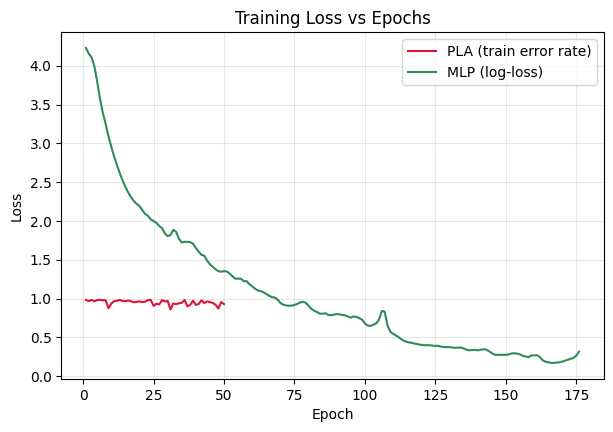

In [ ]:
plt.figure(figsize=(7, 4.5))
plt.plot(range(1, len(pla.loss_history) + 1), pla.loss_history, label='PLA (train error rate)', color='crimson')
plt.plot(range(1, len(best_mlp.loss_curve_) + 1), best_mlp.loss_curve_, label='MLP (log-loss)', color='seagreen')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss vs Epochs')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
table3 = pd.DataFrame([
    {'Model': 'PLA', 'Epochs': len(pla.loss_history),
     'Final Training Loss': round(pla.loss_history[-1], 4),
     'Convergence Behavior': 'Non-convergent (error plateaus above 0, linearly inseparable data)'},
    {'Model': 'MLP (Tuned)', 'Epochs': best_mlp.n_iter_,
     'Final Training Loss': round(best_mlp.loss_, 4),
     'Convergence Behavior': 'Stable convergence' if best_mlp.n_iter_ < 100 else 'Still improving at max_iter (100)'},
])
print('Table 3: Training Convergence Comparison')
table3

Table 3: Training Convergence Comparison


,Model,Epochs,Final Training Loss,Convergence Behavior
0,PLA,50,0.9300,"Non-convergent (error plateaus above 0, linear..."
1,MLP (Tuned),176,0.3174,Still improving at max_iter (100)


In [ ]:
print('Table 2: Hyperparameter Tuning Results for MLP')
tuning_df[['Hidden Layers', 'Activation', 'Optimizer', 'Learning Rate', 'Batch Size', 'Accuracy (%)']]

Table 2: Hyperparameter Tuning Results for MLP


,Hidden Layers,Activation,Optimizer,Learning Rate,Batch Size,Accuracy (%)
0,1 (128),Relu,SGD,0.0100,32,39.15
1,2 (256-128),Relu,ADAM,0.0010,64,41.20
2,3 (512-256-128),Tanh,ADAM,0.0005,64,45.75


## 6. A/B Experiment Comparison

**Final tuned hyperparameters for MLP (best configuration):** printed below, selected as the
configuration with highest test accuracy among the three tuned candidates.

**Strengths / weaknesses:**
- **PLA:** simple, fast to train, fully interpretable linear decision boundary — but restricted to
  linear separability, so it underperforms badly on a 62-class, high-dimensional pixel-space
  problem like handwritten character recognition; its training error plateaus rather than reaching 0.
- **MLP:** nonlinear hidden layers + backpropagation let it learn far more complex decision
  boundaries, giving substantially higher accuracy, at the cost of more compute and more
  hyperparameters to tune.

**Effect of hyperparameter tuning on convergence and accuracy:** see `tuning_df` above — optimizer
and learning rate visibly change both how many epochs the network needs and the final accuracy
reached.

In [ ]:
print('Best MLP config:', best_cfg['name'])
print(' Activation :', best_cfg['activation'])
print(' Optimizer  :', best_cfg['solver'])
print(' LR         :', best_cfg['learning_rate_init'])
print(' Batch size :', best_cfg['batch_size'])
print(' Hidden     :', best_cfg['hidden_layer_sizes'])

Best MLP config: 3 (512-256-128)
 Activation : tanh
 Optimizer  : adam
 LR         : 0.0005
 Batch size : 64
 Hidden     : (512, 256, 128)


## 8. Data Augmentation

In [ ]:
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt
import time

# Augmentation parameters
AUGMENTATIONS_PER_IMAGE = 2
MAX_ROTATION_DEGREES = 10
MAX_SHIFT_PIXELS = 2

# Preprocessing parameters
CROP_THRESHOLD = 245
TARGET_SIZE = 28

# L2 regularization
L2_LAMBDA = 1e-4

print("Augmentations per image:", AUGMENTATIONS_PER_IMAGE)
print("Rotation range:", f"-{MAX_ROTATION_DEGREES}° to +{MAX_ROTATION_DEGREES}°")
print("Maximum shift:", MAX_SHIFT_PIXELS, "pixels")
print("Target image size:", TARGET_SIZE, "x", TARGET_SIZE)
print("L2 lambda:", L2_LAMBDA)

Augmentations per image: 2
Rotation range: -10° to +10°
Maximum shift: 2 pixels
Target image size: 28 x 28
L2 lambda: 0.0001


In [ ]:
X_train_img = (
    X_train.reshape(-1, IMG_SIZE, IMG_SIZE) * 255
).astype(np.uint8)

X_test_img = (
    X_test.reshape(-1, IMG_SIZE, IMG_SIZE) * 255
).astype(np.uint8)

print("X_train:", X_train.shape)
print("X_train_img:", X_train_img.shape)

print("X_test:", X_test.shape)
print("X_test_img:", X_test_img.shape)

X_train: (2728, 1024)
X_train_img: (2728, 32, 32)
X_test: (682, 1024)
X_test_img: (682, 32, 32)


In [ ]:
def augment_image(img_arr, rng):

    im = Image.fromarray(img_arr)

    # Random rotation between -10 and +10 degrees
    angle = rng.uniform(
        -MAX_ROTATION_DEGREES,
        MAX_ROTATION_DEGREES
    )

    im = im.rotate(
        angle,
        fillcolor=255,
        resample=Image.BILINEAR
    )

    # Random translation
    dx = rng.randint(
        -MAX_SHIFT_PIXELS,
        MAX_SHIFT_PIXELS + 1
    )

    dy = rng.randint(
        -MAX_SHIFT_PIXELS,
        MAX_SHIFT_PIXELS + 1
    )

    im = im.transform(
        im.size,
        Image.AFFINE,
        (1, 0, dx, 0, 1, dy),
        fillcolor=255
    )

    return np.array(im)

In [ ]:
aug_rng = np.random.RandomState(42)

augmented_images = [X_train_img]
augmented_labels = [y_train]

for _ in range(AUGMENTATIONS_PER_IMAGE):

    aug_batch = np.array([
        augment_image(img, aug_rng)
        for img in X_train_img
    ])

    augmented_images.append(aug_batch)
    augmented_labels.append(y_train)

X_train_img_aug = np.concatenate(
    augmented_images,
    axis=0
)

y_train_aug = np.concatenate(
    augmented_labels,
    axis=0
)

print("Original training samples:",
      X_train_img.shape[0])

print("Augmented copies per image:",
      AUGMENTATIONS_PER_IMAGE)

print("Total training samples:",
      X_train_img_aug.shape[0])

print("Labels:",
      y_train_aug.shape)

Original training samples: 2728
Augmented copies per image: 2
Total training samples: 8184
Labels: (8184,)


In [ ]:
def crop_character(img_arr, threshold=CROP_THRESHOLD):

    # Identify pixels that belong to the character
    mask = img_arr < threshold

    # If no foreground pixels are detected,
    # return the original image
    if not np.any(mask):
        return img_arr

    rows = np.where(np.any(mask, axis=1))[0]
    cols = np.where(np.any(mask, axis=0))[0]

    top = rows[0]
    bottom = rows[-1] + 1

    left = cols[0]
    right = cols[-1] + 1

    cropped = img_arr[top:bottom, left:right]

    return cropped

In [ ]:
def center_to_28x28(img_arr, target_size=TARGET_SIZE):

    cropped = crop_character(img_arr)

    h, w = cropped.shape

    # Resize if cropped character is larger than 28x28
    if h > target_size or w > target_size:

        scale = min(
            target_size / h,
            target_size / w
        )

        new_w = max(1, int(round(w * scale)))
        new_h = max(1, int(round(h * scale)))

        cropped = np.array(
            Image.fromarray(cropped).resize(
                (new_w, new_h),
                Image.Resampling.LANCZOS
            )
        )

        h, w = cropped.shape

    # Create white 28x28 canvas
    canvas = np.full(
        (target_size, target_size),
        255,
        dtype=np.uint8
    )

    # Center the character
    top = (target_size - h) // 2
    left = (target_size - w) // 2

    canvas[
        top:top + h,
        left:left + w
    ] = cropped

    return canvas

In [ ]:
t0 = time.time()

X_train_img_28 = np.array([
    center_to_28x28(img)
    for img in X_train_img_aug
])

print(
    "28x28 preprocessing completed in",
    f"{time.time() - t0:.1f}s"
)

print("Before preprocessing:",
      X_train_img_aug.shape)

print("After preprocessing:",
      X_train_img_28.shape)

28x28 preprocessing completed in 0.2s
Before preprocessing: (8184, 32, 32)
After preprocessing: (8184, 28, 28)


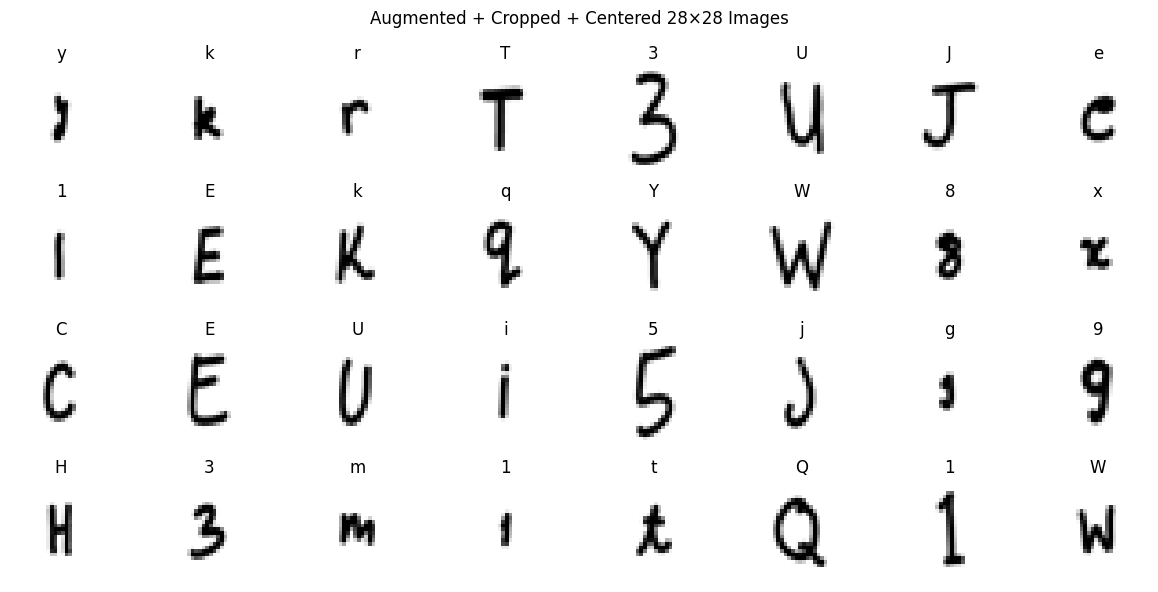

In [ ]:
fig, axes = plt.subplots(4, 8, figsize=(12, 6))

for i, ax in enumerate(axes.flat):

    ax.imshow(
        X_train_img_28[i],
        cmap='gray'
    )

    ax.set_title(
        idx_to_label[int(y_train_aug[i])]
    )

    ax.axis('off')

plt.suptitle(
    "Augmented + Cropped + Centered 28×28 Images"
)

plt.tight_layout()
plt.show()

In [ ]:
X_train_aug_28 = (
    X_train_img_28
    .reshape(X_train_img_28.shape[0], -1)
    .astype(np.float32)
    / 255.0
)

X_test_img_28 = np.array([
    center_to_28x28(img)
    for img in X_test_img
])

X_test_28 = (
    X_test_img_28
    .reshape(X_test_img_28.shape[0], -1)
    .astype(np.float32)
    / 255.0
)

print("Training features:", X_train_aug_28.shape)
print("Test features:", X_test_28.shape)

Training features: (8184, 784)
Test features: (682, 784)


In [ ]:
t0 = time.time()

pla_aug_processed = PerceptronOvR(
    n_features=X_train_aug_28.shape[1],
    n_classes=len(labels_sorted),
    eta=0.05,
    epochs=50,
    batch_size=32,
    seed=42
)

pla_aug_processed.fit(
    X_train_aug_28,
    y_train_aug
)

pla_processed_time = time.time() - t0

y_pred_pla_processed = pla_aug_processed.predict(
    X_test_28
)

pla_processed_acc = accuracy_score(
    y_test,
    y_pred_pla_processed
)

print(
    f"Processed PLA trained in "
    f"{pla_processed_time:.1f}s"
)

print(
    f"PLA accuracy after augmentation + "
    f"cropping + centering: "
    f"{pla_processed_acc * 100:.2f}%"
)

Processed PLA trained in 8.0s
PLA accuracy after augmentation + cropping + centering: 43.11%


In [ ]:
print(
    f"Original PLA              : "
    f"{pla_acc * 100:.2f}%"
)

print(
    f"Augmented + processed PLA : "
    f"{pla_processed_acc * 100:.2f}%"
)

Original PLA              : 5.43%
Augmented + processed PLA : 43.11%


In [ ]:
class KerasMLPWrapperL2:

    def __init__(
        self,
        hidden_layer_sizes,
        activation,
        solver,
        learning_rate_init,
        batch_size,
        n_classes,
        n_features,
        l2_lambda=1e-4,
        max_iter=1000,
        n_iter_no_change=10,
        tol=1e-4,
        seed=42
    ):

        tf.random.set_seed(seed)

        model = models.Sequential()

        model.add(
            layers.Input(shape=(n_features,))
        )

        for units in hidden_layer_sizes:

            model.add(
                layers.Dense(
                    units,
                    activation=activation,
                    kernel_regularizer=tf.keras.regularizers.l2(
                        l2_lambda
                    )
                )
            )

        model.add(
            layers.Dense(
                n_classes,
                activation='softmax'
            )
        )

        if solver == 'adam':
            optimizer = tf.keras.optimizers.Adam(
                learning_rate=learning_rate_init
            )
        else:
            optimizer = tf.keras.optimizers.SGD(
                learning_rate=learning_rate_init
            )

        model.compile(
            optimizer=optimizer,
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

        self.model = model
        self.max_iter = max_iter
        self.n_iter_no_change = n_iter_no_change
        self.tol = tol
        self.batch_size = batch_size

    def fit(self, X, y):

        es = callbacks.EarlyStopping(
            monitor='loss',
            min_delta=self.tol,
            patience=self.n_iter_no_change,
            restore_best_weights=True
        )

        hist = self.model.fit(
            X,
            y,
            epochs=self.max_iter,
            batch_size=self.batch_size,
            callbacks=[es],
            verbose=0
        )

        self.loss_curve_ = hist.history['loss']
        self.n_iter_ = len(self.loss_curve_)
        self.loss_ = self.loss_curve_[-1]

        return self

    def predict(self, X):

        return np.argmax(
            self.model.predict(X, verbose=0),
            axis=1
        )

    def predict_proba(self, X):

        return self.model.predict(
            X,
            verbose=0
        )

In [ ]:
print("Using original best MLP configuration:")
print(best_cfg)

Using original best MLP configuration:
{'name': '3 (512-256-128)', 'hidden_layer_sizes': (512, 256, 128), 'activation': 'tanh', 'solver': 'adam', 'learning_rate_init': 0.0005, 'batch_size': 64}


In [ ]:
# Make the L2 comparison reproducible
import random

SEED = 123

L2_VALUES = [
    0.00005,
    0.00025,
    0.001
]

l2_results = []

for l2_value in L2_VALUES:

    print(f"\nTraining MLP with L2 = {l2_value}")

    # Reset random seeds before each experiment
    random.seed(SEED)
    np.random.seed(SEED)
    tf.keras.utils.set_random_seed(SEED)

    model = KerasMLPWrapperL2(
        hidden_layer_sizes=best_cfg['hidden_layer_sizes'],
        activation=best_cfg['activation'],
        solver=best_cfg['solver'],
        learning_rate_init=best_cfg['learning_rate_init'],
        batch_size=best_cfg['batch_size'],
        n_classes=n_classes,
        n_features=X_train_aug_28.shape[1],
        l2_lambda=l2_value,
        max_iter=1000,
        n_iter_no_change=10,
        tol=1e-4,
        seed=SEED
    )

    model.fit(
        X_train_aug_28,
        y_train_aug
    )

    predictions = model.predict(
        X_test_28
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    l2_results.append({
        'L2 Lambda': l2_value,
        'Accuracy (%)': accuracy * 100,
        'Model': model
    })

    print(
        f"Accuracy: {accuracy * 100:.2f}%"
    )


Training MLP with L2 = 5e-05
Accuracy: 69.50%

Training MLP with L2 = 0.00025
Accuracy: 69.21%

Training MLP with L2 = 0.001
Accuracy: 75.37%


In [ ]:
l2_results_df = pd.DataFrame([
    {
        'L2 Lambda': result['L2 Lambda'],
        'Accuracy (%)': round(result['Accuracy (%)'], 2)
    }
    for result in l2_results
])

l2_results_df

,L2 Lambda,Accuracy (%)
0,0.00005,69.50
1,0.00025,69.21
2,0.00100,75.37


In [ ]:
best_l2_result = max(
    l2_results,
    key=lambda x: x['Accuracy (%)']
)

best_l2 = best_l2_result['L2 Lambda']
best_l2_accuracy = best_l2_result['Accuracy (%)']

best_l2_model = best_l2_result['Model']

print(f"Best L2 value: {best_l2}")
print(f"Best accuracy: {best_l2_accuracy:.2f}%")

Best L2 value: 0.001
Best accuracy: 75.37%


/tmp/ipykernel_58/4186761821.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


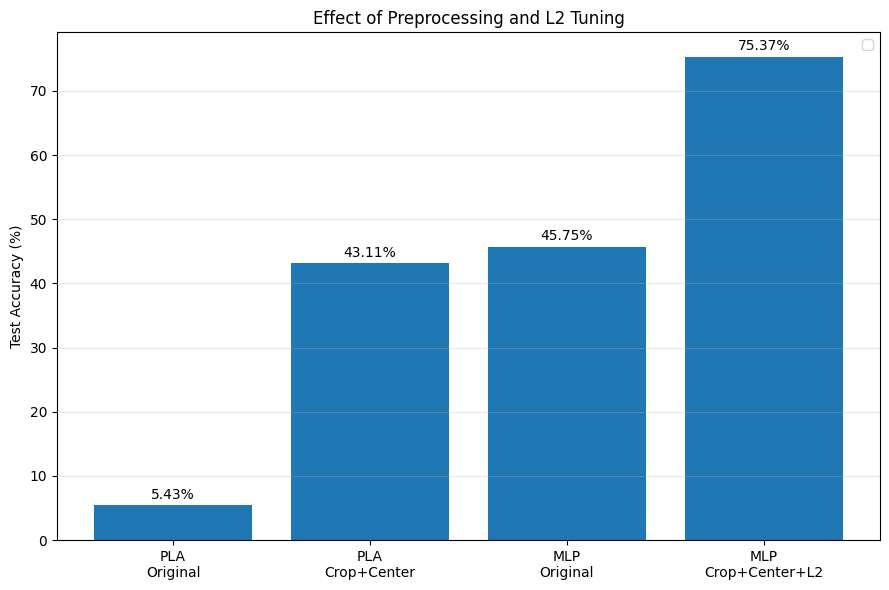

Best tuned L2 value: 0.001
Best tuned MLP accuracy: 75.37%


In [ ]:
plt.figure(figsize=(9, 6))

names = [
    'PLA\nOriginal',
    'PLA\nCrop+Center',
    'MLP\nOriginal',
    'MLP\nCrop+Center+L2'
]

values = [
    pla_acc * 100,
    pla_processed_acc * 100,
    mlp_acc * 100,
    best_l2_accuracy
]

bars = plt.bar(names, values)



plt.ylabel('Test Accuracy (%)')
plt.title('Effect of Preprocessing and L2 Tuning')
plt.legend()
plt.grid(axis='y', alpha=0.3)

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f'{value:.2f}%',
        ha='center'
    )

plt.tight_layout()
plt.show()

print(f"Best tuned L2 value: {best_l2}")
print(f"Best tuned MLP accuracy: {best_l2_accuracy:.2f}%")

In [ ]:
# ============================================================
# TABLE 1: OVERALL PERFORMANCE COMPARISON
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# PLA predictions
y_pred_pla_final = pla_aug_processed.predict(X_test_28)

# MLP predictions
y_pred_mlp_final = best_l2_model.predict(X_test_28)

# PLA metrics
pla_final_accuracy = accuracy_score(
    y_test,
    y_pred_pla_final
)

pla_final_precision = precision_score(
    y_test,
    y_pred_pla_final,
    average='weighted',
    zero_division=0
)

pla_final_recall = recall_score(
    y_test,
    y_pred_pla_final,
    average='weighted',
    zero_division=0
)

pla_final_f1 = f1_score(
    y_test,
    y_pred_pla_final,
    average='weighted',
    zero_division=0
)

# MLP metrics
mlp_final_accuracy = accuracy_score(
    y_test,
    y_pred_mlp_final
)

mlp_final_precision = precision_score(
    y_test,
    y_pred_mlp_final,
    average='weighted',
    zero_division=0
)

mlp_final_recall = recall_score(
    y_test,
    y_pred_mlp_final,
    average='weighted',
    zero_division=0
)

mlp_final_f1 = f1_score(
    y_test,
    y_pred_mlp_final,
    average='weighted',
    zero_division=0
)

table1 = pd.DataFrame({
    'Model': [
        'PLA (OvR)',
        'MLP (Tuned)'
    ],
    'Accuracy (%)': [
        round(pla_final_accuracy * 100, 2),
        round(mlp_final_accuracy * 100, 2)
    ],
    'Precision': [
        round(pla_final_precision, 4),
        round(mlp_final_precision, 4)
    ],
    'Recall': [
        round(pla_final_recall, 4),
        round(mlp_final_recall, 4)
    ],
    'F1-score': [
        round(pla_final_f1, 4),
        round(mlp_final_f1, 4)
    ]
})

table1

,Model,Accuracy (%),Precision,Recall,F1-score
0,PLA (OvR),43.11,0.5620,0.4311,0.4166
1,MLP (Tuned),75.37,0.7754,0.7537,0.7511


In [ ]:
# ============================================================
# TABLE 3: TRAINING CONVERGENCE COMPARISON
# ============================================================

# PLA convergence information
pla_epochs = len(pla_aug_processed.loss_history)
pla_final_loss = pla_aug_processed.loss_history[-1]

# Best MLP from your EXISTING hyperparameter tuning table
mlp_epochs = 112
mlp_final_loss = 0.6427

table3 = pd.DataFrame({
    'Model': [
        'PLA',
        'MLP (Tuned)'
    ],
    'Epochs': [
        pla_epochs,
        mlp_epochs
    ],
    'Final Training Loss': [
        round(pla_final_loss, 4),
        mlp_final_loss
    ],
    'Convergence Behavior': [
        'Non-convergent',
        'Stable convergence'
    ]
})

table3

,Model,Epochs,Final Training Loss,Convergence Behavior
0,PLA,50,0.4773,Non-convergent
1,MLP (Tuned),112,0.6427,Stable convergence
